# EDA: Age Group Prediction
DME-Encoder project — exploratory data analysis for the age-group dataset (Sberbank, 2019).

In [1]:
# Cell 1 — README и описание возрастных групп
from pathlib import Path
from IPython.display import Markdown, display
import pandas as pd

readme_text = Path("../data/raw/age-group/README.md").read_text()
display(Markdown(readme_text))
print(readme_text)

sg_desc = pd.read_csv("../data/raw/age-group/small_group_description.csv")
print("\n=== small_group_description.csv ===")
print(f"Всего категорий: {len(sg_desc)}")
display(sg_desc.head(15))

# Индекс: small_group_code (int) → название
sg_map = sg_desc.set_index("small_group_code")["small_group"]

---
task_categories:
- tabular-classification
tags:
- finance
pretty_name: Age group prediction 2019 competition by Sberbank
configs:
  - config_name: transactions_train
    data_files: transactions_train.csv.gz
  - config_name: transactions_test
    data_files: transactions_test.csv.gz
  - config_name: test_ids
    data_files: test.csv
  - config_name: train_target
    data_files: train_target.csv
---

https://ods.ai/competitions/sberbank-sirius-lesson

---
task_categories:
- tabular-classification
tags:
- finance
pretty_name: Age group prediction 2019 competition by Sberbank
configs:
  - config_name: transactions_train
    data_files: transactions_train.csv.gz
  - config_name: transactions_test
    data_files: transactions_test.csv.gz
  - config_name: test_ids
    data_files: test.csv
  - config_name: train_target
    data_files: train_target.csv
---

https://ods.ai/competitions/sberbank-sirius-lesson

=== small_group_description.csv ===
Всего категорий: 204


,small_group,small_group_code
0,Зоотовары,0
1,Сетевые супермаркеты и продуктовые магазины,1
2,Обслуживание существующего автомобиля (АЗС),2
3,Оплата телефона и связи,3
4,Аптеки,4
5,Авиабилеты,5
6,Duty-free,6
7,Страховка,7
8,Спорт,8
9,Универсальные товары,9


In [2]:
# Cell 2 — Загрузка данных
import numpy as np
import os

os.makedirs("../outputs/figures/eda", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)

txn_train   = pd.read_csv("../data/raw/age-group/transactions_train.csv.gz")
txn_test    = pd.read_csv("../data/raw/age-group/transactions_test.csv.gz")
target      = pd.read_csv("../data/raw/age-group/train_target.csv")
test_ids_df = pd.read_csv("../data/raw/age-group/test.csv")

for name, df in [("transactions_train", txn_train), ("transactions_test", txn_test),
                 ("train_target", target), ("test_ids", test_ids_df)]:
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    display(df.head(3))

# Merge train транзакций с метками
txn_train = txn_train.merge(target, on="client_id", how="left")
print(f"\ntransactions_train после merge: {txn_train.shape}")
display(txn_train.head(3))
print("\nDtypes:")
print(txn_train.dtypes)

# Роли колонок
ENTITY_COL     = "client_id"
TIMESTAMP_COL  = "trans_date"   # целочисленный день (не абсолютная дата)
EVENT_TYPE_COL = "small_group"  # 0–203, уже закодированы
TARGET_COL     = "bins"         # возрастная группа (multiclass)
NUM_COLS       = ["amount_rur"]
CAT_COLS       = []             # нет дополнительных категориальных признаков

print("\n=== Маппинг колонок ===")
role_map = [
    ("client_id",    "entity_id",                   txn_train["client_id"].dtype),
    ("trans_date",   "timestamp (integer day)",     txn_train["trans_date"].dtype),
    ("small_group",  "event_type (0–203)",          txn_train["small_group"].dtype),
    ("amount_rur",   "numerical",                   txn_train["amount_rur"].dtype),
    ("bins",         "target (age group)",          txn_train["bins"].dtype),
]
display(pd.DataFrame(role_map, columns=["column", "role", "dtype"]))
print("\nПримечание: small_group уже закодирован в int, MCC-кодов нет.")
print("small_group_description.csv используется только для интерпретации.")


=== transactions_train ===
Shape: (26450577, 4)


,client_id,trans_date,small_group,amount_rur
0,33172,6,4,71.463
1,33172,6,35,45.017
2,33172,8,11,13.887



=== transactions_test ===
Shape: (17667328, 4)


,client_id,trans_date,small_group,amount_rur
0,46445,3,0,19.555
1,46445,3,1,27.774
2,46445,4,0,18.114



=== train_target ===
Shape: (30000, 2)


...


transactions_train после merge: (26450577, 5)


,client_id,trans_date,small_group,amount_rur,bins
0,33172,6,4,71.463,0
1,33172,6,35,45.017,0
2,33172,8,11,13.887,0



Dtypes:
client_id        int64
trans_date       int64
small_group      int64
amount_rur     float64
bins             int64
dtype: object

=== Маппинг колонок ===


,column,role,dtype
0,client_id,entity_id,int64
1,trans_date,timestamp (integer day),int64
2,small_group,event_type (0–203),int64
3,amount_rur,numerical,float64
4,bins,target (age group),int64



Примечание: small_group уже закодирован в int, MCC-кодов нет.
small_group_description.csv используется только для интерпретации.


Train клиентов: 30,000
Test  клиентов: 20,000



Распределение длин последовательностей (train):
mean       881.7
median     863.0
p75        977.0
p90       1071.0
p95       1108.0
p99       1143.0
max       1150.0

Клиентов с < 5 транзакций: 0 (0.0%)
Рекомендуемый max_seq_len (p95): 1108



Средняя длина последовательности по возрастным группам:


,count,mean,std,min,50%,90%,max
bins,,,,,,,
0,7434.0,892.4,126.2,700.0,878.0,1082.0,1150.0
1,7497.0,859.9,120.0,700.0,833.0,1047.4,1150.0
2,7560.0,889.7,124.6,700.0,876.0,1074.0,1150.0
3,7509.0,884.7,125.6,700.0,867.0,1074.0,1150.0


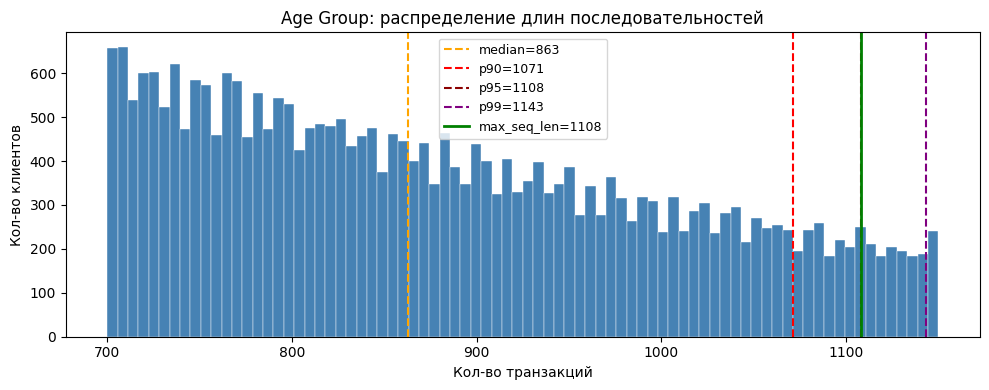

Сохранено: outputs/figures/eda/age_seq_length.png


/var/folders/tt/m44bm46s72n0th3g0b23bqgm0000gn/T/ipykernel_96150/3697777202.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[f"group {g}" for g in sorted(labeled_clients[TARGET_COL].unique())],


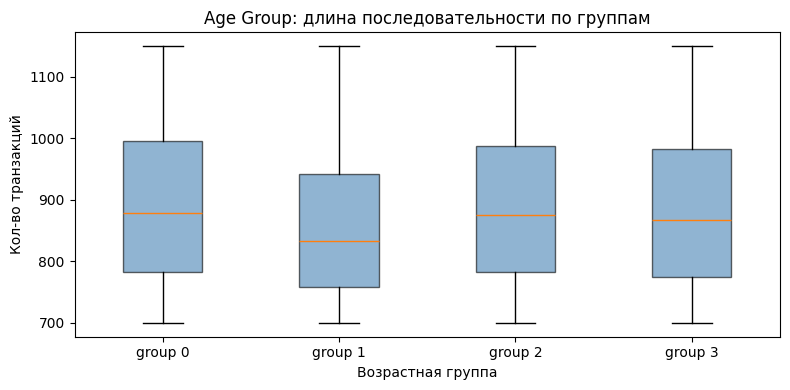

Сохранено: outputs/figures/eda/age_seq_by_class.png


In [3]:
# Cell 3 — Статистика по клиентам
import matplotlib.pyplot as plt

n_train = txn_train[ENTITY_COL].nunique()
n_test  = txn_test[ENTITY_COL].nunique()
print(f"Train клиентов: {n_train:,}")
print(f"Test  клиентов: {n_test:,}")

txn_counts = txn_train.groupby(ENTITY_COL).size()
pcts = txn_counts.quantile([0.50, 0.75, 0.90, 0.95, 0.99])

print("\nРаспределение длин последовательностей (train):")
stats = pd.Series({
    "mean":   txn_counts.mean(),
    "median": txn_counts.median(),
    "p75":    pcts[0.75],
    "p90":    pcts[0.90],
    "p95":    pcts[0.95],
    "p99":    pcts[0.99],
    "max":    txn_counts.max(),
})
print(stats.round(1).to_string())

lt5 = (txn_counts < 5).sum()
print(f"\nКлиентов с < 5 транзакций: {lt5:,} ({100*lt5/n_train:.1f}%)")

recommended_max = int(pcts[0.95])
print(f"Рекомендуемый max_seq_len (p95): {recommended_max}")

# Длина последовательности по bins (возрастным группам)
client_info = txn_train.groupby(ENTITY_COL).agg(
    seq_len=(ENTITY_COL, "count"),
    bins=(TARGET_COL, "first")
).reset_index()
client_info[TARGET_COL] = client_info[TARGET_COL].astype("Int64")

print("\nСредняя длина последовательности по возрастным группам:")
display(
    client_info.groupby(TARGET_COL)["seq_len"]
    .describe(percentiles=[0.5, 0.9])
    .round(1)
)

# Общая гистограмма
fig, ax = plt.subplots(figsize=(10, 4))
clip_v = int(pcts[0.99]) * 1.3
ax.hist(txn_counts.clip(upper=clip_v), bins=80, color="steelblue",
        edgecolor="white", linewidth=0.3)
lc = {"median": "orange", "p90": "red", "p95": "darkred", "p99": "purple"}
for lbl, q in [("median", 0.50), ("p90", 0.90), ("p95", 0.95), ("p99", 0.99)]:
    ax.axvline(pcts[q], color=lc[lbl], linestyle="--", linewidth=1.5,
               label=f"{lbl}={pcts[q]:.0f}")
ax.axvline(recommended_max, color="green", linewidth=2,
           label=f"max_seq_len={recommended_max}")
ax.set_xlabel("Кол-во транзакций")
ax.set_ylabel("Кол-во клиентов")
ax.set_title("Age Group: распределение длин последовательностей")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_seq_length.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/age_seq_length.png")

# Boxplot по группам
labeled_clients = client_info.dropna(subset=[TARGET_COL])
n_bins = int(labeled_clients[TARGET_COL].nunique())
groups = [labeled_clients[labeled_clients[TARGET_COL] == g]["seq_len"].values
          for g in sorted(labeled_clients[TARGET_COL].unique())]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(groups, labels=[f"group {g}" for g in sorted(labeled_clients[TARGET_COL].unique())],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_xlabel("Возрастная группа")
ax.set_ylabel("Кол-во транзакций")
ax.set_title("Age Group: длина последовательности по группам")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_seq_by_class.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/age_seq_by_class.png")

Количество классов: 4

Распределение по классам:


,label,count,%
0,young,7434,24.78
1,young-middle,7497,24.99
2,middle-senior,7560,25.20
3,senior,7509,25.03



Коэффициент дисбаланса (max/min): 1.017
Рекомендуемые class_weights: {0: 1.0089, 1: 1.0004, 2: 0.9921, 3: 0.9988}
Рекомендация: классы относительно сбалансированы

Рекомендуемые метрики для multiclass:
  - macro-F1 (основная)
  - balanced accuracy
  - top-2 accuracy
  - per-class precision/recall


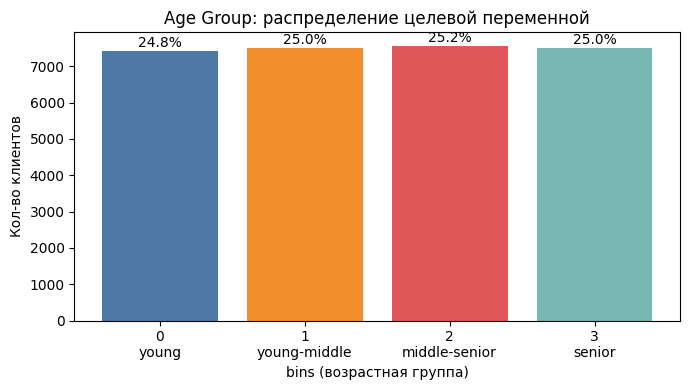

Сохранено: outputs/figures/eda/age_target_distribution.png


In [4]:
# Cell 4 — Целевая переменная (multiclass)
client_bins = txn_train.groupby(ENTITY_COL)[TARGET_COL].first().dropna().astype(int)
n_classes   = client_bins.nunique()
vc          = client_bins.value_counts().sort_index()
vc_pct      = vc / vc.sum() * 100

print(f"Количество классов: {n_classes}")

# Описания из target CSV (если есть)
# bins: 0, 1, 2, 3 — приблизительная интерпретация (молодые → пожилые)
bin_labels = {0: "young", 1: "young-middle", 2: "middle-senior", 3: "senior"}

tdf = pd.DataFrame({
    "label":     pd.Series(bin_labels),
    "count":     vc,
    "%":         vc_pct.round(2),
})
print("\nРаспределение по классам:")
display(tdf)

imbalance = vc.max() / vc.min()
print(f"\nКоэффициент дисбаланса (max/min): {imbalance:.3f}")

# Class weights для multiclass CE loss
total = vc.sum()
class_weights = {int(k): round(total / (n_classes * v), 4) for k, v in vc.items()}
print(f"Рекомендуемые class_weights: {class_weights}")

if imbalance > 2:
    print("Рекомендация: использовать weighted CrossEntropyLoss или StratifiedSampler")
elif imbalance > 1.5:
    print("Рекомендация: class_weights умеренно полезны")
else:
    print("Рекомендация: классы относительно сбалансированы")

print("\nРекомендуемые метрики для multiclass:")
print("  - macro-F1 (основная)")
print("  - balanced accuracy")
print("  - top-2 accuracy")
print("  - per-class precision/recall")

# График
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f"{k}\n{bin_labels.get(k, '')}" for k in vc.index],
              vc.values, color=colors[:len(vc)])
for bar, pct in zip(bars, vc_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("bins (возрастная группа)")
ax.set_ylabel("Кол-во клиентов")
ax.set_title("Age Group: распределение целевой переменной")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_target_distribution.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/age_target_distribution.png")

Уникальных small_group: 202  (из 204 возможных)

Топ-30 small_group (event_type):


,count,%,description
small_group,,,
1,8131374,30.742,Сетевые супермаркеты и продуктовые магазины
11,3202881,12.109,Фастфуд и кафе
3,2428984,9.183,Оплата телефона и связи
15,1427077,5.395,Несетевые супермаркеты и продуктовые магазины
4,1207604,4.566,Аптеки
18,1158512,4.380,Рестораны и кафе
2,908408,3.434,Обслуживание существующего автомобиля (АЗС)
12,773805,2.925,Такси и каршеринги
25,702896,2.657,Метро (паромы и Ж\Д аналоги)



Редких (count <  5): 8
Редких (count < 10): 12
Доля топ-10 в объёме: 78.0%



Доля топ-10 small_group по возрастным группам (%):


small_group,1,2,3,4,9,11,12,15,18,25
bins,,,,,,,,,,
0,36.35,4.90,11.44,5.35,3.33,17.04,4.90,6.76,6.36,3.57
1,46.04,4.60,11.79,7.86,3.58,10.10,1.50,7.90,4.73,1.90
2,35.43,2.66,11.28,4.08,2.94,20.82,5.62,6.27,5.78,5.12
3,40.08,5.58,12.63,6.24,3.54,13.79,2.86,6.79,5.58,2.93


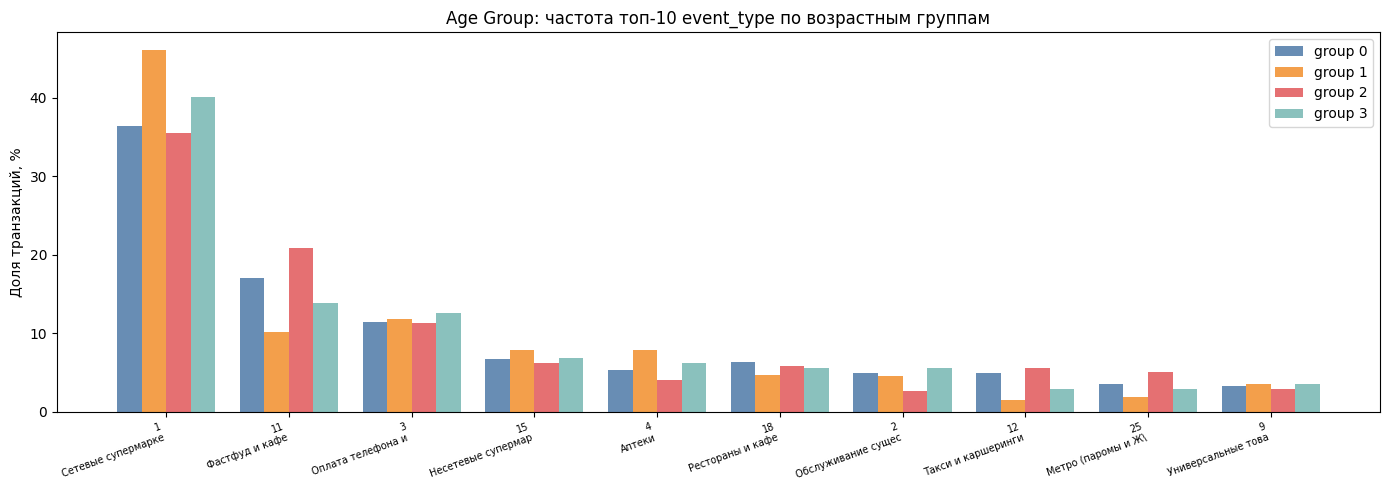

Сохранено: outputs/figures/eda/age_event_by_class.png


In [5]:
# Cell 5 — Анализ event_type (small_group)
n_unique_sg = txn_train[EVENT_TYPE_COL].nunique()
total_txn   = len(txn_train)
print(f"Уникальных small_group: {n_unique_sg}  (из {len(sg_desc)} возможных)")

sg_counts = txn_train[EVENT_TYPE_COL].value_counts()
top30 = sg_counts.head(30)
top30_df = pd.DataFrame({"count": top30, "%": (top30 / total_txn * 100).round(3)})
top30_df["description"] = top30_df.index.map(sg_map).fillna("—")
print("\nТоп-30 small_group (event_type):")
display(top30_df)

rare_lt5  = (sg_counts < 5).sum()
rare_lt10 = (sg_counts < 10).sum()
top10_sh  = sg_counts.head(10).sum() / total_txn * 100
print(f"\nРедких (count <  5): {rare_lt5}")
print(f"Редких (count < 10): {rare_lt10}")
print(f"Доля топ-10 в объёме: {top10_sh:.1f}%")

# Различия по возрастным группам: топ-10 event_type
top10_sg  = sg_counts.head(10).index.tolist()
txn_lbl   = txn_train[txn_train[TARGET_COL].notna()].copy()
txn_lbl[TARGET_COL] = txn_lbl[TARGET_COL].astype(int)

freq_by_cls = (
    txn_lbl[txn_lbl[EVENT_TYPE_COL].isin(top10_sg)]
    .groupby([TARGET_COL, EVENT_TYPE_COL])
    .size()
    .unstack(EVENT_TYPE_COL)
    .fillna(0)
)
freq_norm = freq_by_cls.div(freq_by_cls.sum(axis=1), axis=0) * 100
print("\nДоля топ-10 small_group по возрастным группам (%):")
display(freq_norm.round(2))

# Grouped bar chart
x  = np.arange(len(top10_sg))
w  = 0.2
clrs = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]
fig, ax = plt.subplots(figsize=(14, 5))
for i, grp in enumerate(sorted(freq_norm.index)):
    ax.bar(x + i * w, freq_norm.loc[grp, top10_sg].values, w,
           label=f"group {grp}", color=clrs[i % len(clrs)], alpha=0.85)
ax.set_xticks(x + w * (len(freq_norm) - 1) / 2)
ax.set_xticklabels(
    [f"{g}\n{sg_map.get(g,'')[:18]}" for g in top10_sg],
    fontsize=7, rotation=20, ha="right"
)
ax.set_ylabel("Доля транзакций, %")
ax.set_title("Age Group: частота топ-10 event_type по возрастным группам")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_event_by_class.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/age_event_by_class.png")

Статистика time_delta (дни):


mean        0.82
median      1.00
p75         1.00
p90         2.00
p99         5.00
max       115.00

Доля нулевых дельт (одновременные): 44.63%
Доля отрицательных дельт (аномалии):  0.00%



Mean/Median ratio: 1.5x — умеренное распределение



Частота транзакций (txn/день) по возрастным группам:


,count,mean,std,min,50%,max
grp,,,,,,
0,7434.0,1.230,0.174,0.959,1.210,1.708
1,7497.0,1.183,0.165,0.959,1.146,1.669
2,7560.0,1.228,0.172,0.959,1.209,1.745
3,7509.0,1.217,0.172,0.959,1.193,1.746


/var/folders/tt/m44bm46s72n0th3g0b23bqgm0000gn/T/ipykernel_96150/3405005530.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups_td,


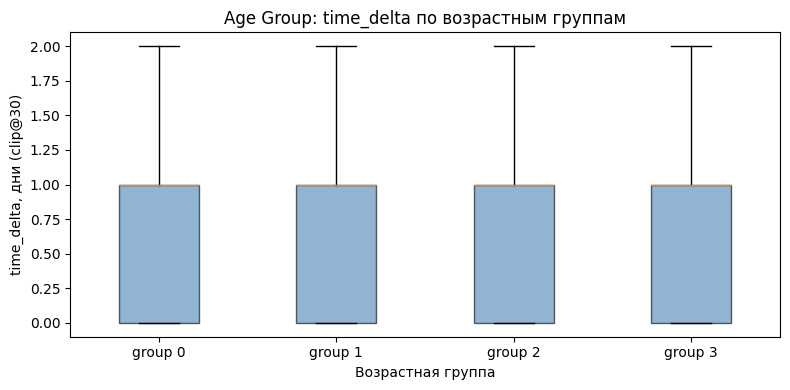

Сохранено: outputs/figures/eda/age_time_delta_by_class.png


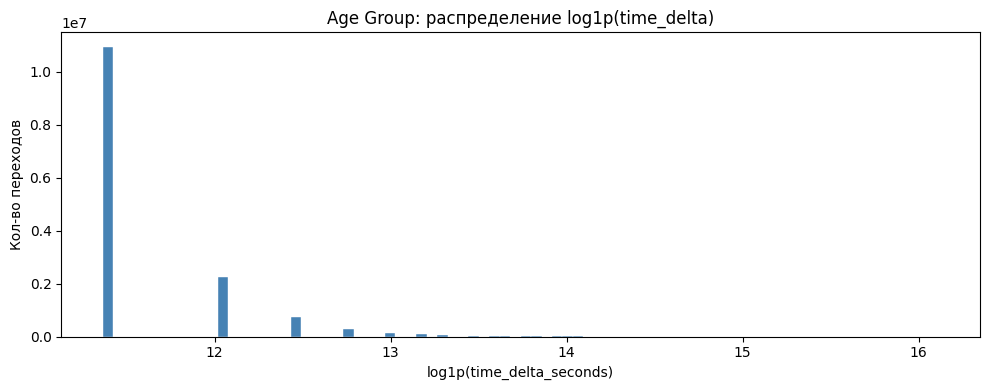

In [6]:
# Cell 6 — Анализ time_delta
# trans_date — целое число дней; time_delta = diff в днях
txn_sorted = txn_train.sort_values([ENTITY_COL, TIMESTAMP_COL])
td_days = txn_sorted.groupby(ENTITY_COL)[TIMESTAMP_COL].diff()  # дни
td_sec  = td_days * 86400  # в секунды для совместимости с другими датасетами

td_valid = td_sec.dropna()
pct_td   = td_valid.quantile([0.50, 0.75, 0.90, 0.99])

print("Статистика time_delta (дни):")
td_days_valid = td_days.dropna()
stats_td = pd.Series({
    "mean":   td_days_valid.mean(),
    "median": td_days_valid.median(),
    "p75":    td_days_valid.quantile(0.75),
    "p90":    td_days_valid.quantile(0.90),
    "p99":    td_days_valid.quantile(0.99),
    "max":    td_days_valid.max(),
})
print(stats_td.round(2).to_string())

zero_frac = (td_valid == 0).mean() * 100
neg_frac  = (td_valid < 0).mean() * 100
print(f"\nДоля нулевых дельт (одновременные): {zero_frac:.2f}%")
print(f"Доля отрицательных дельт (аномалии):  {neg_frac:.2f}%")

td_pos = td_days_valid[td_days_valid > 0]
ratio  = td_pos.mean() / max(td_pos.median(), 1e-9)
print(f"\nMean/Median ratio: {ratio:.1f}x — ", end="")
if ratio > 3:
    print("heavy tail → рекомендован log1p")
else:
    print("умеренное распределение")

# Сравнение частоты транзакций между группами (среднее кол-во транзакций / день)
txn_lbl2 = txn_train[txn_train[TARGET_COL].notna()].copy()
txn_lbl2[TARGET_COL] = txn_lbl2[TARGET_COL].astype(int)
span_per_client = txn_lbl2.groupby(ENTITY_COL).agg(
    date_span=(TIMESTAMP_COL, lambda x: x.max() - x.min() + 1),
    n_txn=(TIMESTAMP_COL, "count"),
    grp=(TARGET_COL, "first")
)
span_per_client["txn_per_day"] = span_per_client["n_txn"] / span_per_client["date_span"].clip(lower=1)
print("\nЧастота транзакций (txn/день) по возрастным группам:")
display(
    span_per_client.groupby("grp")["txn_per_day"]
    .describe(percentiles=[0.5])
    .round(3)
)

# Boxplot time_delta по группам
td_merged = td_days.rename("td_days").to_frame()
td_merged[ENTITY_COL] = txn_sorted[ENTITY_COL].values
td_merged = td_merged.dropna()
td_merged = td_merged.merge(
    txn_train[[ENTITY_COL, TARGET_COL]].dropna().drop_duplicates(ENTITY_COL),
    on=ENTITY_COL, how="left"
)
td_merged = td_merged[td_merged[TARGET_COL].notna() & (td_merged["td_days"] >= 0)]
td_merged[TARGET_COL] = td_merged[TARGET_COL].astype(int)
groups_td = [td_merged[td_merged[TARGET_COL] == g]["td_days"].clip(upper=30).values
             for g in sorted(td_merged[TARGET_COL].unique())]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(groups_td,
           labels=[f"group {g}" for g in sorted(td_merged[TARGET_COL].unique())],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_xlabel("Возрастная группа")
ax.set_ylabel("time_delta, дни (clip@30)")
ax.set_title("Age Group: time_delta по возрастным группам")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_time_delta_by_class.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/age_time_delta_by_class.png")

# Гистограмма log1p
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(td_pos * 86400), bins=80, color="steelblue",
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("log1p(time_delta_seconds)")
ax.set_ylabel("Кол-во переходов")
ax.set_title("Age Group: распределение log1p(time_delta)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_time_delta.png", dpi=150)
plt.show()

In [7]:
# Cell 7 — Анализ числовых признаков (amount_rur)
print("=== amount_rur ===")
s = txn_train["amount_rur"]

pct99    = s.quantile(0.99)
pct_null = s.isna().mean() * 100
pct_zero = (s == 0).mean() * 100
pct_neg  = (s < 0).mean() * 100
skewness = s.dropna().skew()

print(f"mean:      {s.mean():.3f}")
print(f"std:       {s.std():.3f}")
print(f"min:       {s.min():.3f}")
print(f"max:       {s.max():.3f}")
print(f"p99:       {pct99:.3f}")
print(f"% null:    {pct_null:.2f}%")
print(f"% zero:    {pct_zero:.2f}%")
print(f"% neg:     {pct_neg:.2f}%")
print(f"skewness:  {skewness:.2f}")

if pct_neg > 1:
    rec = "sign * log1p(|amount_rur|)"
elif abs(skewness) > 2:
    rec = "RobustScaler / log1p"
else:
    rec = "StandardScaler"
print(f"\nРекомендация: {rec}")

# Различия между группами
txn_lbl3 = txn_train[txn_train[TARGET_COL].notna()].copy()
txn_lbl3[TARGET_COL] = txn_lbl3[TARGET_COL].astype(int)

print("\nРаспределение amount_rur по возрастным группам:")
grp_stats = txn_lbl3.groupby(TARGET_COL)["amount_rur"].describe(percentiles=[0.5, 0.9])
display(grp_stats.round(2))

# Средний чек по группам
mean_by_grp = txn_lbl3.groupby(TARGET_COL)["amount_rur"].mean()
print("\nСредний чек по группам:")
print(mean_by_grp.round(3).to_string())
if mean_by_grp.max() / max(mean_by_grp.min(), 1e-9) > 1.3:
    print("Вывод: средний чек значимо различается между группами — признак информативен")
else:
    print("Вывод: средний чек схож между группами")

=== amount_rur ===


mean:      55.862


std:       369.485
min:       0.001
max:       400086.790
p99:       560.891
% null:    0.00%
% zero:    0.00%
% neg:     0.00%
skewness:  247.95

Рекомендация: RobustScaler / log1p



Распределение amount_rur по возрастным группам:


,count,mean,std,min,50%,90%,max
bins,,,,,,,
0,6634365.0,52.63,281.47,0.0,19.67,95.63,168189.31
1,6446923.0,71.80,542.78,0.0,24.96,123.47,400086.79
2,6726439.0,31.86,162.57,0.0,13.28,61.63,132256.81
3,6642850.0,67.93,388.33,0.0,24.13,122.78,238089.67



Средний чек по группам:
bins
0    52.626
1    71.802
2    31.861
3    67.927
Вывод: средний чек значимо различается между группами — признак информативен


Топ-15 переходов (from → to):


,from,from_desc,to,to_desc,count
0,1,Сетевые супермаркеты и продуктовые магазины,1,Сетевые супермаркеты и продуктовые магазины,2088064
1,1,Сетевые супермаркеты и продуктовые магазины,11,Фастфуд и кафе,1426476
2,3,Оплата телефона и связи,1,Сетевые супермаркеты и продуктовые магазины,1101052
3,11,Фастфуд и кафе,1,Сетевые супермаркеты и продуктовые магазины,791632
4,1,Сетевые супермаркеты и продуктовые магазины,3,Оплата телефона и связи,633795
5,15,Несетевые супермаркеты и продуктовые магазины,1,Сетевые супермаркеты и продуктовые магазины,553584
6,1,Сетевые супермаркеты и продуктовые магазины,4,Аптеки,525799
7,18,Рестораны и кафе,1,Сетевые супермаркеты и продуктовые магазины,511066
8,4,Аптеки,1,Сетевые супермаркеты и продуктовые магазины,423157
9,1,Сетевые супермаркеты и продуктовые магазины,15,Несетевые супермаркеты и продуктовые магазины,422958



Средняя энтропия строк (топ-20): 3.099 бит
Максимальная (равномерная):       4.322 бит
Вывод: переходы относительно равномерны


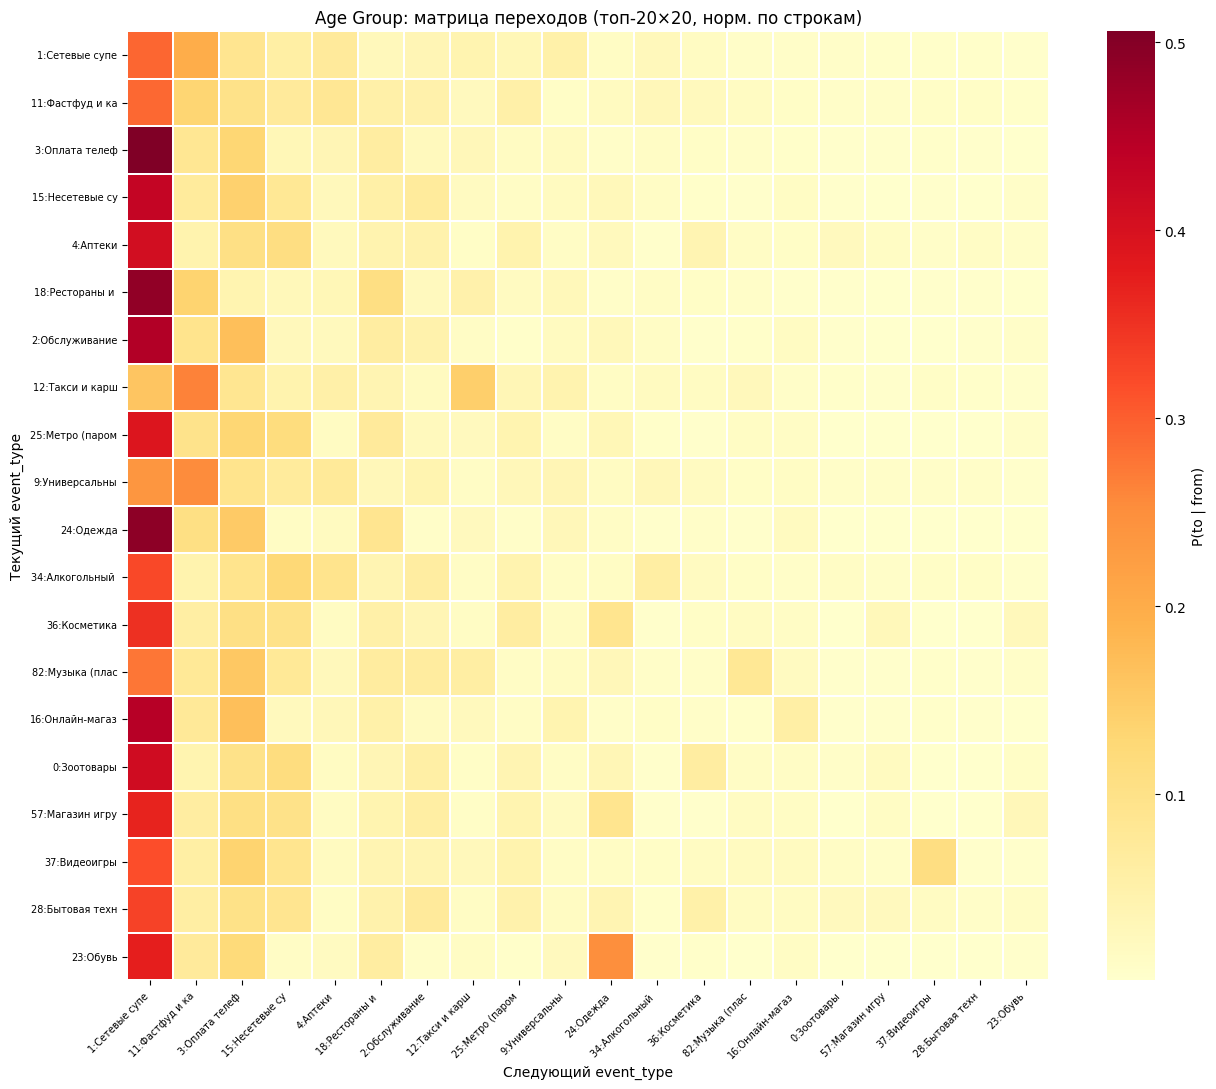

Сохранено: outputs/figures/eda/age_transitions.png



Матрица переходов для группы 0 (youngest) vs 3 (oldest):
Топ-10 наибольших различий P(to|from):
  1(Сетевые супермаркеты) → 11(Фастфуд и кафе): Δ=0.053
  12(Такси и каршеринги) → 11(Фастфуд и кафе): Δ=0.047
  9(Универсальные товары) → 11(Фастфуд и кафе): Δ=0.046
  24(Одежда) → 1(Сетевые супермаркеты): Δ=0.042
  1(Сетевые супермаркеты) → 1(Сетевые супермаркеты): Δ=0.042
  3(Оплата телефона и св) → 1(Сетевые супермаркеты): Δ=0.039
  15(Несетевые супермарке) → 1(Сетевые супермаркеты): Δ=0.038
  36(Косметика) → 1(Сетевые супермаркеты): Δ=0.035
  23(Обувь) → 1(Сетевые супермаркеты): Δ=0.034
  25(Метро (паромы и Ж\Д ) → 1(Сетевые супермаркеты): Δ=0.032


In [8]:
# Cell 8 — Transition matrix
import seaborn as sns
from scipy.stats import entropy
from collections import Counter

# Полная матрица переходов (train)
txn_s = txn_train.sort_values([ENTITY_COL, TIMESTAMP_COL])
pairs_all = []
for _, grp in txn_s.groupby(ENTITY_COL)[EVENT_TYPE_COL]:
    seq = grp.tolist()
    pairs_all.extend(zip(seq[:-1], seq[1:]))

pair_counts = Counter(pairs_all)
top15 = pair_counts.most_common(15)
print("Топ-15 переходов (from → to):")
top15_df = pd.DataFrame(top15, columns=["transition", "count"])
top15_df["from"]      = top15_df["transition"].apply(lambda x: x[0])
top15_df["to"]        = top15_df["transition"].apply(lambda x: x[1])
top15_df["from_desc"] = top15_df["from"].map(sg_map).fillna("—")
top15_df["to_desc"]   = top15_df["to"].map(sg_map).fillna("—")
display(top15_df[["from", "from_desc", "to", "to_desc", "count"]])

# Топ-20 для heatmap
top20_sg = txn_train[EVENT_TYPE_COL].value_counts().head(20).index.tolist()
mat = pd.DataFrame(0, index=top20_sg, columns=top20_sg, dtype=float)
for (a, b), cnt in pair_counts.items():
    if a in mat.index and b in mat.columns:
        mat.loc[a, b] += cnt

row_sums = mat.sum(axis=1).replace(0, 1)
mat_norm = mat.div(row_sums, axis=0)

row_ent  = mat_norm.apply(lambda r: entropy(r + 1e-12, base=2), axis=1)
mean_ent = row_ent.mean()
max_ent  = np.log2(len(top20_sg))
print(f"\nСредняя энтропия строк (топ-20): {mean_ent:.3f} бит")
print(f"Максимальная (равномерная):       {max_ent:.3f} бит")
if mean_ent < 0.5 * max_ent:
    print("Вывод: переходы СТРУКТУРИРОВАНЫ → transition-aware replacement полезен")
else:
    print("Вывод: переходы относительно равномерны")

# Heatmap общей матрицы
tick_labels = [f"{g}:{sg_map.get(g,'')[:12]}" for g in top20_sg]
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(mat_norm, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "P(to | from)"},
            xticklabels=tick_labels, yticklabels=tick_labels)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
ax.set_xlabel("Следующий event_type")
ax.set_ylabel("Текущий event_type")
ax.set_title("Age Group: матрица переходов (топ-20×20, норм. по строкам)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/age_transitions.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/age_transitions.png")

# Сравнение крайних групп
bin_classes = sorted(txn_lbl2[TARGET_COL].unique())
youngest_ids = set(txn_lbl2[txn_lbl2[TARGET_COL] == bin_classes[0]][ENTITY_COL].unique())
oldest_ids   = set(txn_lbl2[txn_lbl2[TARGET_COL] == bin_classes[-1]][ENTITY_COL].unique())

def build_mat(ids, label):
    sub = txn_s[txn_s[ENTITY_COL].isin(ids)]
    p = []
    for _, g in sub.groupby(ENTITY_COL)[EVENT_TYPE_COL]:
        seq = g.tolist(); p.extend(zip(seq[:-1], seq[1:]))
    pc = Counter(p)
    m = pd.DataFrame(0, index=top20_sg, columns=top20_sg, dtype=float)
    for (a, b), cnt in pc.items():
        if a in m.index and b in m.columns:
            m.loc[a, b] += cnt
    rs = m.sum(axis=1).replace(0, 1)
    return m.div(rs, axis=0)

mat_y = build_mat(youngest_ids, "youngest")
mat_o = build_mat(oldest_ids,   "oldest")

print(f"\nМатрица переходов для группы {bin_classes[0]} (youngest) vs {bin_classes[-1]} (oldest):")
diff_mat = (mat_y - mat_o).abs()
top_diff = diff_mat.stack().nlargest(10)
print("Топ-10 наибольших различий P(to|from):")
for (fr, to), d in top_diff.items():
    print(f"  {fr}({sg_map.get(fr,'')[:20]}) → {to}({sg_map.get(to,'')[:20]}): Δ={d:.3f}")

In [9]:
# Cell 9 — Проверка качества
print("=== Проверка качества ===")

train_ids_set  = set(txn_train[ENTITY_COL].unique())
test_ids_set   = set(txn_test[ENTITY_COL].unique())
target_ids_set = set(target[ENTITY_COL].unique())
test_list_set  = set(test_ids_df[ENTITY_COL].unique())

# Клиенты в train_target но без транзакций
target_no_txn = target_ids_set - train_ids_set
print(f"Клиентов в train_target без транзакций:  {len(target_no_txn):,}")

# Клиенты в transactions_train но без метки
txn_no_target = train_ids_set - target_ids_set
print(f"Клиентов в transactions_train без метки: {len(txn_no_target):,}")

# Покрытие test
test_no_txn = test_list_set - test_ids_set
print(f"Клиентов из test.csv без транзакций:     {len(test_no_txn):,}")

# Пересечение train и test
overlap = train_ids_set & test_ids_set
print(f"Пересечение train ∩ test клиентов:       {len(overlap):,}")

# Дубликаты
dup_train = txn_train.duplicated(subset=[ENTITY_COL, TIMESTAMP_COL, EVENT_TYPE_COL]).sum()
dup_test  = txn_test.duplicated(subset=[ENTITY_COL, TIMESTAMP_COL, EVENT_TYPE_COL]).sum()
print(f"\nДубликаты в transactions_train: {dup_train:,}")
print(f"Дубликаты в transactions_test:  {dup_test:,}")

# Аномалии trans_date
print(f"\nДиапазон trans_date (train): {txn_train[TIMESTAMP_COL].min()} — {txn_train[TIMESTAMP_COL].max()} дней")
neg_dates = (txn_train[TIMESTAMP_COL] < 0).sum()
print(f"Отрицательных trans_date: {neg_dates:,}")

# Пропуски
print("\nПропуски в ключевых полях (train):")
for col in [ENTITY_COL, TIMESTAMP_COL, EVENT_TYPE_COL, "amount_rur"]:
    n = txn_train[col].isna().sum()
    print(f"  {col}: {n:,}")

=== Проверка качества ===


Клиентов в train_target без транзакций:  0
Клиентов в transactions_train без метки: 0
Клиентов из test.csv без транзакций:     0
Пересечение train ∩ test клиентов:       0



Дубликаты в transactions_train: 0
Дубликаты в transactions_test:  0

Диапазон trans_date (train): 0 — 729 дней
Отрицательных trans_date: 0

Пропуски в ключевых полях (train):
  client_id: 0
  trans_date: 0
  small_group: 0


  amount_rur: 0


In [10]:
# Cell 10 — Сравнение с другими датасетами
import json

with open("../outputs/metrics/eda_rosbank.json") as f:
    r = json.load(f)
with open("../outputs/metrics/eda_gender.json") as f:
    g = json.load(f)

# age_group метрики (текущие)
txn_cnt_all = pd.concat([
    txn_train.groupby(ENTITY_COL).size(),
    txn_test.groupby(ENTITY_COL).size()
])
pcts_all = txn_train.groupby(ENTITY_COL).size().quantile([0.50, 0.90, 0.95, 0.99])
n_classes_a = int(target[TARGET_COL].nunique())
vc_a = target[TARGET_COL].value_counts()
imb_a = round(float(vc_a.max() / vc_a.min()), 3)

compare = pd.DataFrame({
    "Метрика": [
        "n_train_entities",
        "n_test_entities",
        "n_train_events",
        "median_seq_len",
        "p90_seq_len",
        "p95_seq_len",
        "n_event_types",
        "task_type",
        "n_classes",
        "class_imbalance_ratio",
        "use_log1p_time",
        "recommended_scaler",
    ],
    "Rosbank": [
        r["n_train_clients"],
        r["n_test_clients"],
        r["n_train_txn"],
        r["median_seq_len"],
        r["p90_seq_len"],
        r["p95_seq_len"],
        r["vocab_size"],
        "binary (churn)",
        2,
        r["class_imbalance_ratio"],
        r["use_log1p_time"],
        r["recommended_scaler"],
    ],
    "Gender": [
        g["n_train_clients"],
        g["n_test_clients"],
        g["n_total_txn"],
        g["median_seq_len"],
        g["p90_seq_len"],
        g["p95_seq_len"],
        g["vocab_size_mcc"],
        "binary (gender)",
        2,
        g["class_imbalance_ratio"],
        g["use_log1p_time"],
        g["recommended_scaler"],
    ],
    "Age Group": [
        int(len(target_ids_set)),
        int(len(test_list_set)),
        int(len(txn_train)),
        int(pcts_all[0.50]),
        int(pcts_all[0.90]),
        int(pcts_all[0.95]),
        int(txn_train[EVENT_TYPE_COL].nunique()),
        "multiclass (age)",
        n_classes_a,
        imb_a,
        bool(td_days_valid[td_days_valid > 0].mean() > 3 * td_days_valid[td_days_valid > 0].median()),
        rec,  # из Cell 7
    ],
})
print("=== Сравнение датасетов ===")
display(compare.set_index("Метрика"))

=== Сравнение датасетов ===


,Rosbank,Gender,Age Group
Метрика,,,
n_train_entities,5000,8400,30000
n_test_entities,5217,3600,20000
n_train_events,490513,6849346,26450577
median_seq_len,83,324,863
p90_seq_len,203,858,1071
p95_seq_len,243,1089,1108
n_event_types,344,184,202
task_type,binary (churn),binary (gender),multiclass (age)
n_classes,2,2,4


In [11]:
# Cell 11 — Итоги и сохранение

# Пересчитываем ключевые метрики
pcts_train = txn_train.groupby(ENTITY_COL).size().quantile([0.95, 0.99])
max_seq_rec = int(pcts_train[0.95])

vc_bins = target[TARGET_COL].value_counts()
imb_bins = float(vc_bins.max() / vc_bins.min())
n_cls = int(target[TARGET_COL].nunique())
total_b = vc_bins.sum()
cw = {int(k): round(float(total_b) / (n_cls * v), 4) for k, v in vc_bins.items()}

td_pos2 = td_days_valid[td_days_valid > 0]
use_log1p_t = bool(td_pos2.mean() > 3 * td_pos2.median())

s_a = txn_train["amount_rur"]
pct_neg_a = float((s_a < 0).mean() * 100)
if pct_neg_a > 1:
    rec_scaler_a = "sign*log1p"
elif abs(s_a.skew()) > 2:
    rec_scaler_a = "RobustScaler"
else:
    rec_scaler_a = "StandardScaler"

top20_a = txn_train[EVENT_TYPE_COL].value_counts().head(20).index.tolist()
mat_a = pd.DataFrame(0, index=top20_a, columns=top20_a, dtype=float)
for (a2, b2), cnt2 in pair_counts.items():
    if a2 in mat_a.index and b2 in mat_a.columns:
        mat_a.loc[a2, b2] += cnt2
rs_a = mat_a.sum(axis=1).replace(0, 1)
mn_a = mat_a.div(rs_a, axis=0)
me_a = mn_a.apply(lambda r: entropy(r + 1e-12, base=2), axis=1).mean()
trans_useful = bool(me_a < 0.5 * np.log2(20))

recs = {
    "max_seq_len":               max_seq_rec,
    "min_seq_len":               2,
    "vocab_size":                int(txn_train[EVENT_TYPE_COL].nunique()),
    "n_classes":                 n_cls,
    "class_distribution":        {int(k): int(v) for k, v in vc_bins.items()},
    "class_imbalance_ratio":     round(imb_bins, 4),
    "recommended_class_weights": cw,
    "use_log1p_time":            use_log1p_t,
    "recommended_scaler":        rec_scaler_a,
    "amount_has_negatives_pct":  round(pct_neg_a, 2),
    "transition_aware_useful":   trans_useful,
    "n_train_clients":           int(len(target_ids_set)),
    "n_test_clients":            int(len(test_list_set)),
    "n_train_txn":               int(len(txn_train)),
    "n_test_txn":                int(len(txn_test)),
    "mean_seq_len":              round(float(txn_train.groupby(ENTITY_COL).size().mean()), 2),
    "median_seq_len":            int(txn_train.groupby(ENTITY_COL).size().median()),
    "p90_seq_len":               int(txn_train.groupby(ENTITY_COL).size().quantile(0.90)),
    "p95_seq_len":               int(pcts_train[0.95]),
    "p99_seq_len":               int(pcts_train[0.99]),
    "mean_entropy_transitions":  round(float(me_a), 4),
    "recommended_metrics":       ["macro_f1", "balanced_accuracy", "top2_accuracy"],
}

print("=== Итоговые рекомендации ===")
display(pd.Series({
    k: v for k, v in recs.items() if not isinstance(v, (dict, list))
}).to_frame("value"))
print(f"\nclass_distribution: {recs['class_distribution']}")
print(f"class_weights:       {recs['recommended_class_weights']}")
print(f"metrics:             {recs['recommended_metrics']}")

with open("../outputs/metrics/eda_age_group.json", "w") as f:
    json.dump(recs, f, indent=2)
print("\nСохранено: outputs/metrics/eda_age_group.json")

# Финальная сравнительная таблица
print("\n=== Финальная сравнительная таблица ===")
display(compare.set_index("Метрика"))
print("\nAge Group EDA complete.")

=== Итоговые рекомендации ===


,value
max_seq_len,1108
min_seq_len,2
vocab_size,202
n_classes,4
class_imbalance_ratio,1.0169
use_log1p_time,False
recommended_scaler,RobustScaler
amount_has_negatives_pct,0.0
transition_aware_useful,False
n_train_clients,30000



class_distribution: {2: 7560, 3: 7509, 1: 7497, 0: 7434}
class_weights:       {2: 0.9921, 3: 0.9988, 1: 1.0004, 0: 1.0089}
metrics:             ['macro_f1', 'balanced_accuracy', 'top2_accuracy']

Сохранено: outputs/metrics/eda_age_group.json

=== Финальная сравнительная таблица ===


,Rosbank,Gender,Age Group
Метрика,,,
n_train_entities,5000,8400,30000
n_test_entities,5217,3600,20000
n_train_events,490513,6849346,26450577
median_seq_len,83,324,863
p90_seq_len,203,858,1071
p95_seq_len,243,1089,1108
n_event_types,344,184,202
task_type,binary (churn),binary (gender),multiclass (age)
n_classes,2,2,4



Age Group EDA complete.
